In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")

import seaborn as sns
sns.set_style("darkgrid")
%config InlineBackend.figure_format = "svg"

# Car Price Analysis

* Read in the dataset `car_prices.csv` using the code below.
* Run the info and describe DataFrame methods to get a quick understanding of the data.

In [ ]:
from google.colab import files
upload_cars = files.upload()

Saving car_prices.csv to car_prices (4).csv


In [ ]:
cars = pd.read_csv("car_prices.csv",
                   on_bad_lines='skip'
                   )

In [ ]:
cars.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,"kia motors america, inc",20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,"kia motors america, inc",20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500,27750,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000,67000,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
cars.shape

(558811, 16)

In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558811 entries, 0 to 558810
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558811 non-null  int64  
 1   make          548510 non-null  object 
 2   model         548412 non-null  object 
 3   trim          548160 non-null  object 
 4   body          545616 non-null  object 
 5   transmission  493458 non-null  object 
 6   vin           558811 non-null  object 
 7   state         558811 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558717 non-null  float64
 10  color         558062 non-null  object 
 11  interior      558062 non-null  object 
 12  seller        558811 non-null  object 
 13  mmr           558811 non-null  int64  
 14  sellingprice  558811 non-null  int64  
 15  saledate      558811 non-null  object 
dtypes: float64(2), int64(3), object(11)
memory usage: 68.2+ MB


In [ ]:
cars.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558811 entries, 0 to 558810
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558811 non-null  int64  
 1   make          548510 non-null  object 
 2   model         548412 non-null  object 
 3   trim          548160 non-null  object 
 4   body          545616 non-null  object 
 5   transmission  493458 non-null  object 
 6   vin           558811 non-null  object 
 7   state         558811 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558717 non-null  float64
 10  color         558062 non-null  object 
 11  interior      558062 non-null  object 
 12  seller        558811 non-null  object 
 13  mmr           558811 non-null  int64  
 14  sellingprice  558811 non-null  int64  
 15  saledate      558811 non-null  object 
dtypes: float64(2), int64(3), object(11)
memory usage: 371.5 MB


In [ ]:
for col in cars.columns:
  print(cars[col].value_counts(), end = "\n" + "*" * 50 + "\n")

year
2012    102315
2013     98168
2014     81070
2011     48548
2008     31502
2007     30845
2006     26913
2010     26485
2005     21394
2009     20594
2004     17342
2003     13281
2002      9715
2015      9411
2001      6468
2000      5227
1999      3363
1998      2149
1997      1546
1996       851
1995       711
1994       392
1993       205
1992       132
1991        67
1990        49
1989        20
1986        11
1988        11
1985        10
1987         8
1984         5
1982         2
1983         1
Name: count, dtype: int64
**************************************************
make
Ford          93554
Chevrolet     60197
Nissan        53946
Toyota        39871
Dodge         30710
              ...  
ford tk           1
chev truck        1
airstream         1
dot               1
Lotus             1
Name: count, Length: 96, dtype: int64
**************************************************
model
Altima        19349
F-150         14479
Fusion        12946
Camry         12545
Escape  

In [ ]:
categorical_list = ["make" , "model" , "trim" ,"transmission" ,"state","color", "interior" ,"body"]
categorical_dtypes = ["category"] * len(categorical_list)
categorical_dtypes

['category',
 'category',
 'category',
 'category',
 'category',
 'category',
 'category',
 'category']

In [ ]:
categorical_columns = dict(zip(categorical_list , categorical_dtypes))
categorical_columns

{'make': 'category',
 'model': 'category',
 'trim': 'category',
 'transmission': 'category',
 'state': 'category',
 'color': 'category',
 'interior': 'category',
 'body': 'category'}

In [ ]:
cars = cars.astype(categorical_columns)

In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558811 entries, 0 to 558810
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   year          558811 non-null  int64   
 1   make          548510 non-null  category
 2   model         548412 non-null  category
 3   trim          548160 non-null  category
 4   body          545616 non-null  category
 5   transmission  493458 non-null  category
 6   vin           558811 non-null  object  
 7   state         558811 non-null  category
 8   condition     547017 non-null  float64 
 9   odometer      558717 non-null  float64 
 10  color         558062 non-null  category
 11  interior      558062 non-null  category
 12  seller        558811 non-null  object  
 13  mmr           558811 non-null  int64   
 14  sellingprice  558811 non-null  int64   
 15  saledate      558811 non-null  object  
dtypes: category(8), float64(2), int64(3), object(3)
memory usage: 39.6+ MB


In [ ]:
 (
    pd.to_datetime(cars["saledate"], errors="coerce", utc=True)
        .dt.tz_localize(None)      # remove timezone
        .dt.normalize()            # remove hours
)

/tmp/ipython-input-2596842740.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(cars["saledate"], errors="coerce", utc=True)


,saledate
0,2014-12-16
1,2014-12-16
2,2015-01-14
3,2015-01-28
4,2014-12-18
...,...
558806,2015-07-09
558807,2015-07-08
558808,2015-07-08
558809,2015-07-08


In [ ]:
cars["saledate"] = (
    pd.to_datetime(cars["saledate"] ,
    errors="coerce",
    utc = True
    ).
    dt.tz_localize(None). # remove timezone
    dt.normalize() # remove hours
)
cars.saledate

/tmp/ipython-input-1879655600.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(cars["saledate"] ,


,saledate
0,2014-12-16
1,2014-12-16
2,2015-01-14
3,2015-01-28
4,2014-12-18
...,...
558806,2015-07-09
558807,2015-07-08
558808,2015-07-08
558809,2015-07-08


In [ ]:
cars.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558811 entries, 0 to 558810
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   year          558811 non-null  int64         
 1   make          548510 non-null  category      
 2   model         548412 non-null  category      
 3   trim          548160 non-null  category      
 4   body          545616 non-null  category      
 5   transmission  493458 non-null  category      
 6   vin           558811 non-null  object        
 7   state         558811 non-null  category      
 8   condition     547017 non-null  float64       
 9   odometer      558717 non-null  float64       
 10  color         558062 non-null  category      
 11  interior      558062 non-null  category      
 12  seller        558811 non-null  object        
 13  mmr           558811 non-null  int64         
 14  sellingprice  558811 non-null  int64         
 15  saledate      558

In [ ]:
cars.describe()

,year,condition,odometer,mmr,sellingprice,saledate
count,558811.000000,547017.000000,558717.000000,558811.000000,558811.000000,558811
mean,2010.038696,3.424512,68323.195797,13769.324646,13611.262461,2015-03-05 08:06:35.141828352
min,1982.000000,1.000000,1.000000,25.000000,1.000000,2014-01-01 00:00:00
25%,2007.000000,2.700000,28374.000000,7100.000000,6900.000000,2015-01-20 00:00:00
50%,2012.000000,3.600000,52256.000000,12250.000000,12100.000000,2015-02-12 00:00:00
75%,2013.000000,4.200000,99112.000000,18300.000000,18200.000000,2015-05-21 00:00:00
max,2015.000000,5.000000,999999.000000,182000.000000,230000.000000,2015-07-20 00:00:00
std,3.966812,0.949439,53397.752933,9679.874607,9749.656919,NaN


In [ ]:
cars.select_dtypes(include="number").describe().iloc[1: , ]

,year,condition,odometer,mmr,sellingprice
mean,2010.038696,3.424512,68323.195797,13769.324646,13611.262461
std,3.966812,0.949439,53397.752933,9679.874607,9749.656919
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,2.700000,28374.000000,7100.000000,6900.000000
50%,2012.000000,3.600000,52256.000000,12250.000000,12100.000000
75%,2013.000000,4.200000,99112.000000,18300.000000,18200.000000
max,2015.000000,5.000000,999999.000000,182000.000000,230000.000000


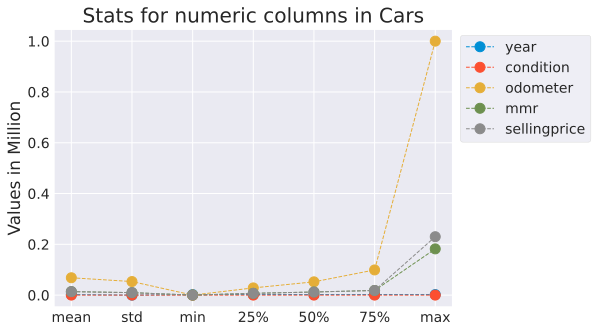

In [ ]:
cars.select_dtypes(include="number").div(10**6).describe().iloc[1: , ].plot(marker = "o" ,
                                                                            ms = 10 ,
                                                                            ls = "--",
                                                                            lw = 1 ,
                                                                            title = "Stats for numeric columns in Cars",
                                                                            legend = True)
plt.legend(bbox_to_anchor = (1,1))
plt.ylabel("Values in Million")
plt.show()

In [ ]:
cars.select_dtypes("datetime").describe().iloc[1: , ].T

,mean,min,25%,50%,75%,max
saledate,2015-03-05 08:06:35.141828352,2014-01-01 00:00:00,2015-01-20 00:00:00,2015-02-12 00:00:00,2015-05-21 00:00:00,2015-07-20 00:00:00


In [ ]:
cars.select_dtypes("object").describe().iloc[1: , ].T

,unique,top,freq
vin,550296,wbanv13588cz57827,5
seller,14264,nissan-infiniti lt,19693


# Numeric Variable Relationships

Use a pairplot to get a good sense for the relationships between the numeric variables in the dataset.

Turn off the upper corner of the pairplot matrix.

* Why do you think the relationship between `sellingprice` and `mmr` (the recommended selling price) is so strong?
* What is the relationship between `sellingprice` and `year` (the year the car was manufactured). Does this make sense?
* Once you've looked at the two relationships above, filter your dataframe down to the `body` styles ['SUV', 'Sedan', 'Convertible', and 'Coupe']. Color the scatterplot based on values in the `body` column.

In [ ]:
len(cars)

558811

C:\Users\ahmad\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


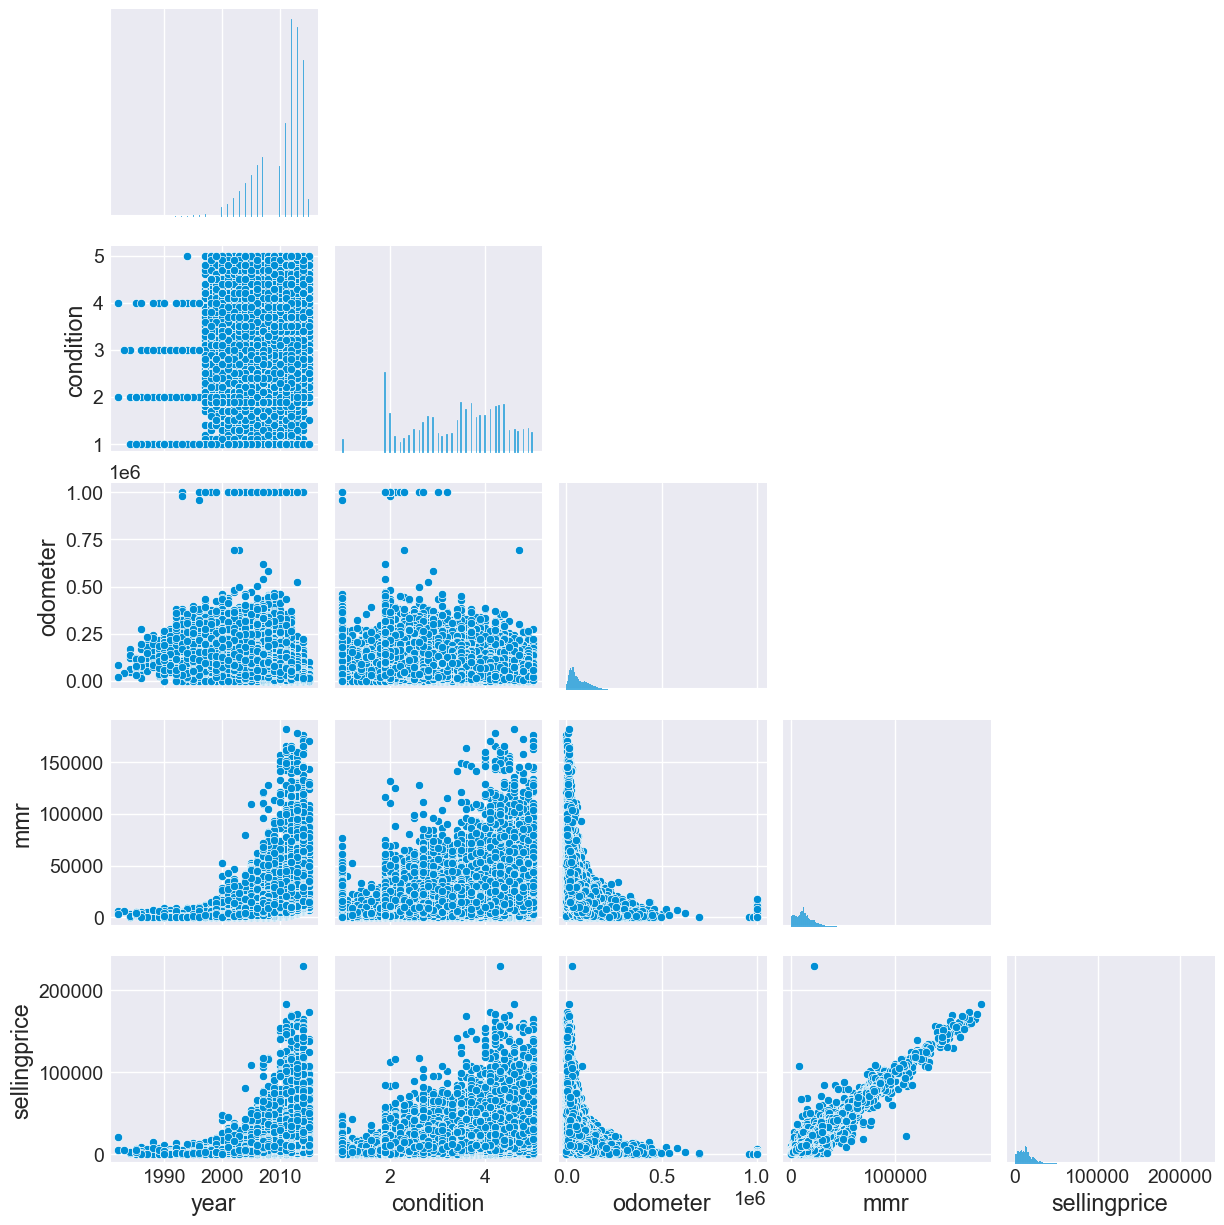

In [ ]:
sns.pairplot(cars,
             corner = True)
sns.despine()

* Why do you think the relationship between sellingprice and mmr (the recommended selling price) is so strong?

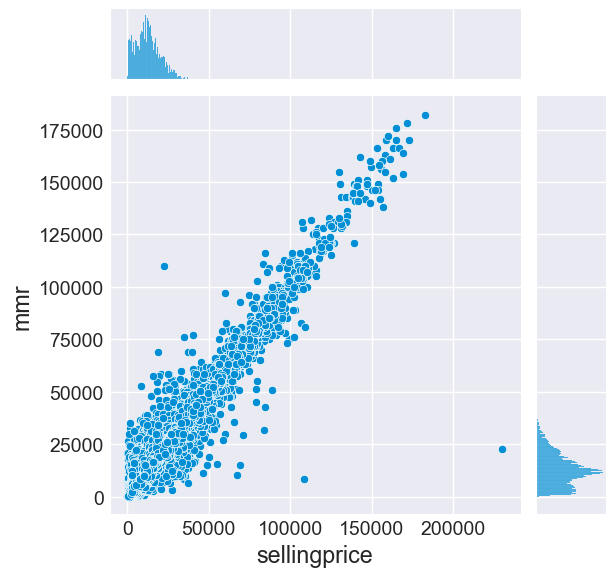

In [ ]:
sns.jointplot(data = cars , x ="sellingprice" , y = "mmr" )
sns.despine()

* What is the relationship between `sellingprice` and `year` (the year the car was manufactured). Does this make sense?

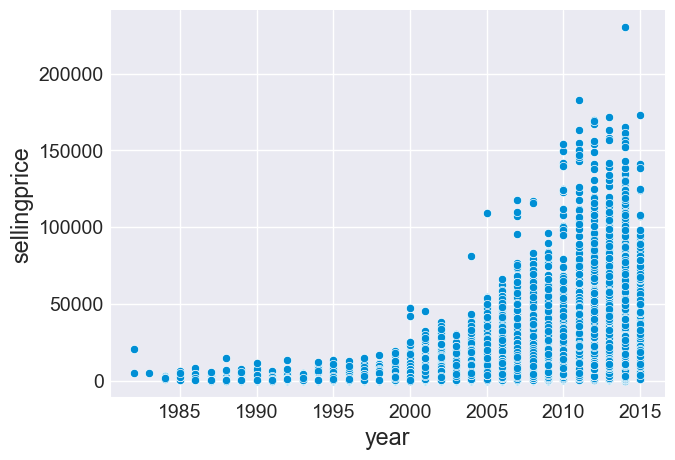

In [ ]:
sns.scatterplot(data = cars , x = "year" , y = "sellingprice")
sns.despine()

* Once you've looked at the two relationships above, filter your dataframe down to the `body` styles ['SUV', 'Sedan', 'Convertible', and 'Coupe']. Color the scatterplot based on values in the `body` column.

In [ ]:
cars.body = cars.body.astype("object")

In [ ]:
style_list = ["SUV", "Sedan", "Convertible", "Coupe"]

In [ ]:
cars.loc[(cars.body.isin(style_list))]

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,"kia motors america, inc",20500,21500,2014-12-16
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,"kia motors america, inc",20800,21500,2014-12-16
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900,30000,2015-01-14
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500,27750,2015-01-28
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000,67000,2014-12-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558803,2012,Hyundai,Elantra,Limited,Sedan,NaN,5npdh4ae7ch106397,pa,4.0,66720.0,gray,gray,champion mazda,10250,10400,2015-07-08
558804,2012,Nissan,Sentra,2.0 SR,Sedan,NaN,3n1ab6ap3cl622485,tn,2.6,35858.0,white,gray,nissan-infiniti lt,9950,10400,2015-07-08
558805,2011,BMW,5 Series,528i,Sedan,automatic,wbafr1c53bc744672,fl,3.9,66403.0,white,brown,lauderdale imports ltd bmw pembrok pines,20300,22800,2015-07-06
558806,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,4.5,18255.0,silver,black,avis corporation,35300,33000,2015-07-09


In [ ]:
filtered_cars = cars.query("body in @style_list")
filtered_cars

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,"kia motors america, inc",20500,21500,2014-12-16
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,"kia motors america, inc",20800,21500,2014-12-16
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900,30000,2015-01-14
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500,27750,2015-01-28
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000,67000,2014-12-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558803,2012,Hyundai,Elantra,Limited,Sedan,NaN,5npdh4ae7ch106397,pa,4.0,66720.0,gray,gray,champion mazda,10250,10400,2015-07-08
558804,2012,Nissan,Sentra,2.0 SR,Sedan,NaN,3n1ab6ap3cl622485,tn,2.6,35858.0,white,gray,nissan-infiniti lt,9950,10400,2015-07-08
558805,2011,BMW,5 Series,528i,Sedan,automatic,wbafr1c53bc744672,fl,3.9,66403.0,white,brown,lauderdale imports ltd bmw pembrok pines,20300,22800,2015-07-06
558806,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,4.5,18255.0,silver,black,avis corporation,35300,33000,2015-07-09


In [ ]:
filtered_cars.body.value_counts().nlargest(4).index.to_list()

['Sedan', 'SUV', 'Coupe', 'Convertible']

In [ ]:
cars.loc[(cars.body.isin(style_list))]["body"].value_counts()

body
Sedan          199437
SUV            119292
Coupe           14602
Convertible      8652
Name: count, dtype: int64

In [ ]:
cars.body

0               SUV
1               SUV
2             Sedan
3             Sedan
4             Sedan
            ...    
558806        Sedan
558807     Crew Cab
558808          SUV
558809        sedan
558810    SuperCrew
Name: body, Length: 558811, dtype: object

C:\Users\ahmad\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


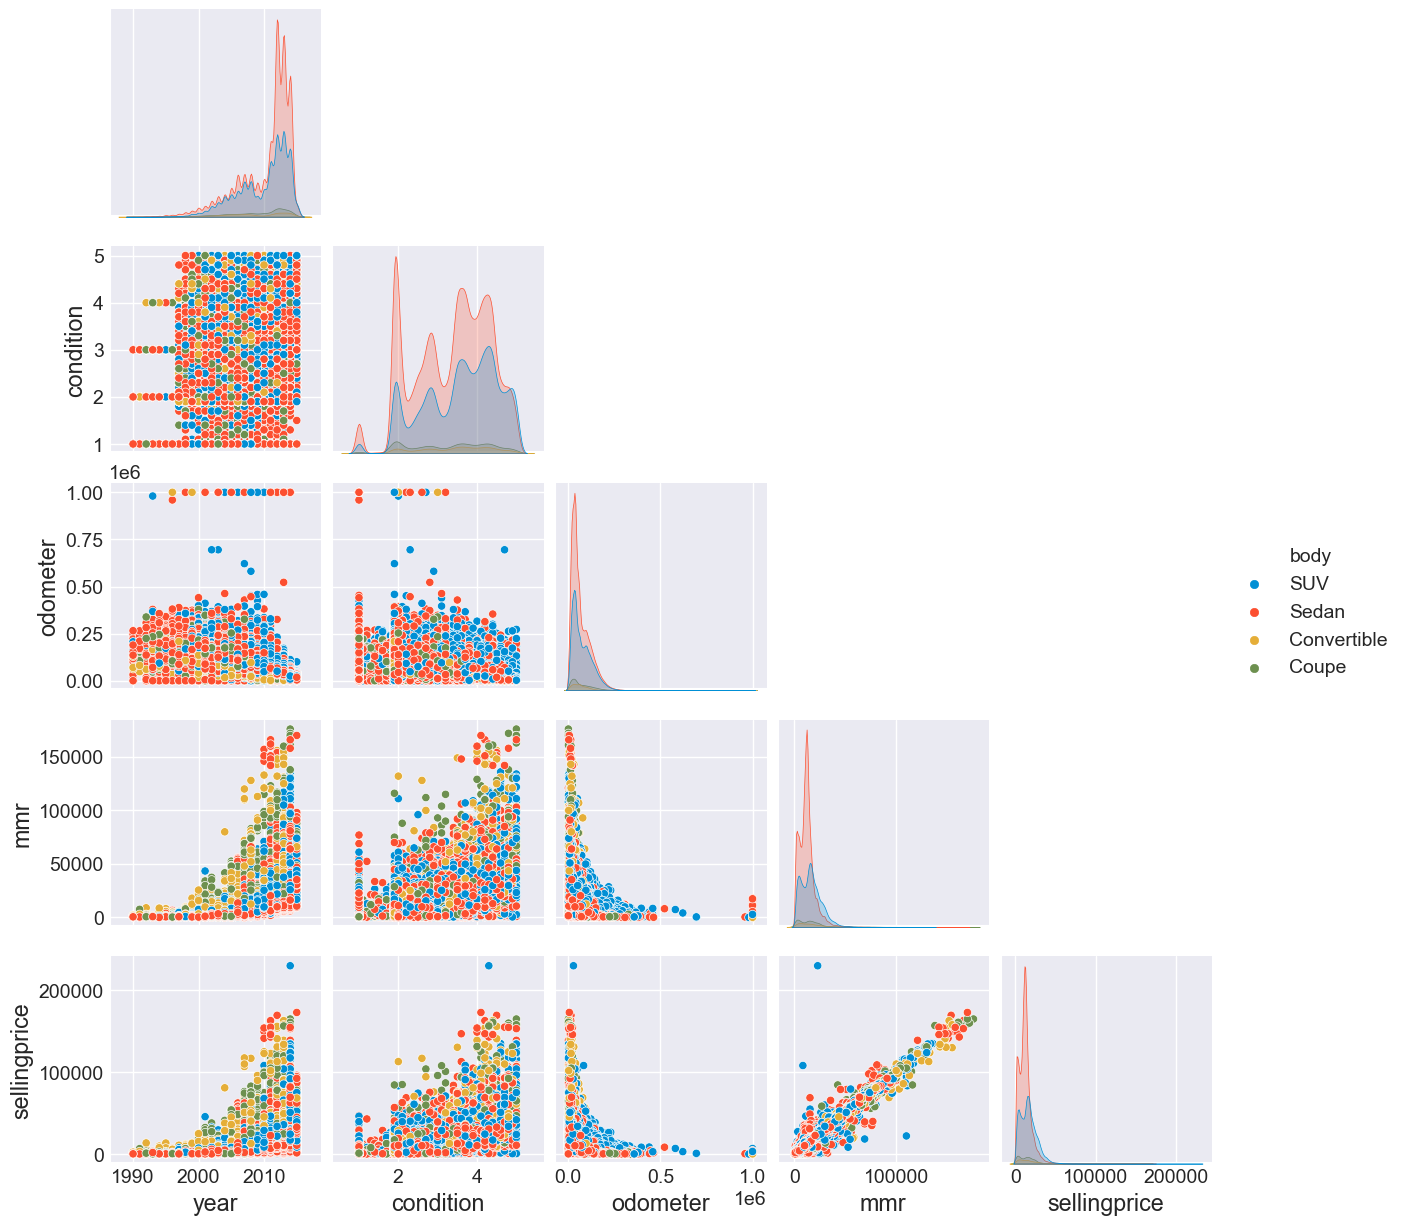

In [ ]:
sns.pairplot(data = cars.loc[(cars.body.isin(style_list))],
             hue = "body" ,
             corner = True ,
             diag_kind = "kde")
sns.despine()

In [ ]:
cars.body = cars.body.astype("category")